In [1]:
%%writefile kaggle.json
{
  "username":"anjanitiwarit22",
  "key":"KGAT_be3171d646bf844221f30c7af967c5fd"
}

Writing kaggle.json


In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [3]:
!kaggle datasets list

ref                                                             title                                                 size  lastUpdated                 downloadCount  voteCount  usabilityRating  
--------------------------------------------------------------  ----------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
rauffauzanrambe/fifa-world-cup-2026-player-performance-dataset  FIFA World Cup 2026 Player Performance Dataset     4154062  2026-06-10 12:58:47.093000          12775        311                1  
abbas829/ecommerce-sales-dataset                                Ecommerce sales dataset                             110951  2026-07-03 00:59:03.347000           1908         39                1  
ashyou09/global-budget-allocation-dataset-19362026              Global Budget Allocation Dataset (1936–2026) 🌎      295046  2026-07-11 08:11:16.587000           1024         31                1  
ashyou09/apple-produ

In [4]:
!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset

Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 157M/157M [00:00<00:00, 165MB/s]



In [5]:
!unzip brain-tumor-mri-dataset.zip -d /content/brain_mri

Streaming output truncated to the last 5000 lines.
  inflating: /content/brain_mri/Training/glioma/Tr-gl_279.jpg  
  inflating: /content/brain_mri/Training/glioma/Tr-gl_28.jpg  
  inflating: /content/brain_mri/Training/glioma/Tr-gl_280.jpg  
  inflating: /content/brain_mri/Training/glioma/Tr-gl_281.jpg  
  inflating: /content/brain_mri/Training/glioma/Tr-gl_282.jpg  
  inflating: /content/brain_mri/Training/glioma/Tr-gl_283.jpg  
  inflating: /content/brain_mri/Training/glioma/Tr-gl_284.jpg  
  inflating: /content/brain_mri/Training/glioma/Tr-gl_285.jpg  
  inflating: /content/brain_mri/Training/glioma/Tr-gl_286.jpg  
  inflating: /content/brain_mri/Training/glioma/Tr-gl_287.jpg  
  inflating: /content/brain_mri/Training/glioma/Tr-gl_288.jpg  
  inflating: /content/brain_mri/Training/glioma/Tr-gl_289.jpg  
  inflating: /content/brain_mri/Training/glioma/Tr-gl_29.jpg  
  inflating: /content/brain_mri/Training/glioma/Tr-gl_290.jpg  
  inflating: /content/brain_mri/Training/glioma/Tr-gl_2

In [6]:
import os

for root, dirs, files in os.walk("/content/brain_mri"):
    print(root, len(files))
    break

/content/brain_mri 0


In [ ]:
import os

print(os.listdir("/content/brain_mri"))

['Testing', 'Training']


In [ ]:
import os  
import numpy as
import random  
from PIL import 
from tensorflow.keras.preprocessing.image 
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import Input, Flatten, Dropout, Dense 
from tensorflow.keras.optimizers import Adam  
from tensorflow.keras.applications import VGG16  
from sklearn.utils import shuffle  

In [ ]:
train_dir = "/content/brain_mri/Training"
test_dir = "/content/brain_mri/Testing"
train_dir

'/content/brain_mri/Training'

In [ ]:
import os

print(os.listdir(train_dir))
print(os.listdir(test_dir))

['notumor', 'pituitary', 'glioma', 'meningioma']
['notumor', 'pituitary', 'glioma', 'meningioma']


In [ ]:

train_paths = []
train_labels = []
for label in os.listdir(train_dir):
    for image in os.listdir(os.path.join(train_dir, label)):
        train_paths.append(os.path.join(train_dir, label, image))
        train_labels.append(label)

train_paths, train_labels = shuffle(train_paths, train_labels)

test_paths = []
test_labels = []
for label in os.listdir(test_dir):
    for image in os.listdir(os.path.join(test_dir, label)):
        test_paths.append(os.path.join(test_dir, label, image))
        test_labels.append(label)

test_paths, test_labels = shuffle(test_paths, test_labels)

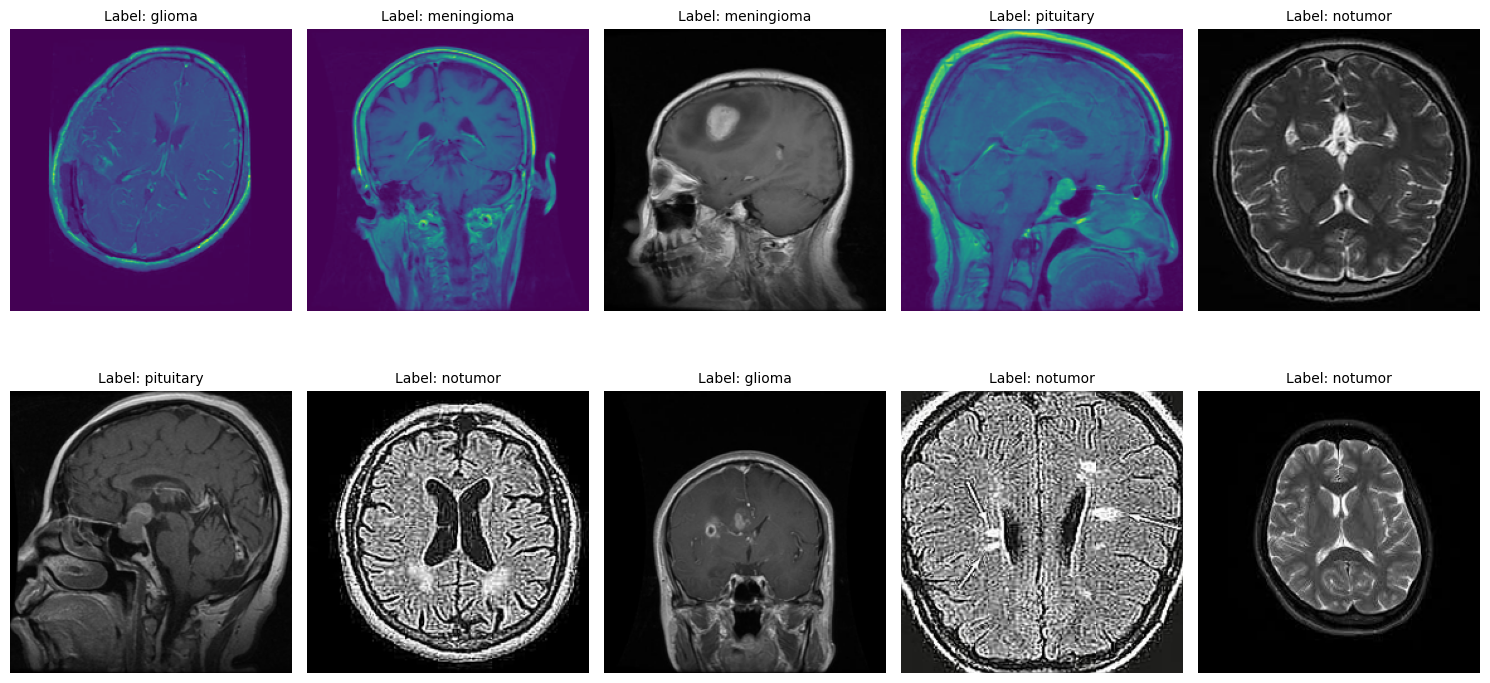

In [ ]:
import random
import matplotlib.pyplot as plt
from PIL import Image
import os
random_indices = random.sample(range(len(train_paths)), 10)
fig, axes = plt.subplots(2, 5, figsize=(15, 8))
axes = axes.ravel()
for i, idx in enumerate(random_indices):
    img_path = train_paths[idx]
    img = Image.open(img_path)
    img = img.resize((224, 224))
    axes[i].imshow(img)
    axes[i].axis('off')
    axes[i].set_title(f"Label: {train_labels[idx]}", fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:

def augment_image(image):
    image = Image.fromarray(np.uint8(image))
    image = ImageEnhance.Brightness(image).enhance(random.uniform(0.8, 1.2))
    image = ImageEnhance.Contrast(image).enhance(random.uniform(0.8, 1.2))
    image = np.array(image) / 255.0
    return image

def open_images(paths):
    images = []
    for path in paths:
        image = load_img(path, target_size=(IMAGE_SIZE, IMAGE_SIZE))
        image = augment_image(image)
        images.append(image)
    return np.array(images)

def encode_label(labels):
    unique_labels = os.listdir(train_dir)
    encoded = [unique_labels.index(label) for label in labels]
    return np.array(encoded)

def datagen(paths, labels, batch_size=12, epochs=1):
    for _ in range(epochs):
        for i in range(0, len(paths), batch_size):
            batch_paths = paths[i:i + batch_size]
            batch_images = open_images(batch_paths)
            batch_labels = labels[i:i + batch_size]
            batch_labels = encode_label(batch_labels)
            yield batch_images, batch_labels

In [ ]:
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2
import math

IMAGE_SIZE = 224
base_model = VGG16(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3), include_top=False, weights='imagenet')

for layer in base_model.layers:
    layer.trainable = False

base_model.layers[-2].trainable = True
base_model.layers[-3].trainable = True
base_model.layers[-4].trainable = True

model = Sequential()
model.add(Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)))
model.add(base_model)
model.add(Flatten())
model.add(Dense(128, activation='relu', kernel_regularizer=l2(1e-4)))
model.add(BatchNormalization())
model.add(Dropout(0.4))
model.add(Dense(len(os.listdir(train_dir)), activation='softmax'))

model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='sparse_categorical_crossentropy',
              metrics=['sparse_categorical_accuracy'])
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

batch_size = 20
steps = math.ceil(len(train_paths) / batch_size)
epochs = 10

history1 = model.fit(datagen(train_paths, train_labels, batch_size=batch_size, epochs=epochs),
                    epochs=epochs, steps_per_epoch=steps,validation_data=datagen(test_paths,test_labels,batch_size=batch_size,epochs=epochs),
                    validation_steps=int(len(test_paths) / batch_size),callbacks=[early_stop])


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 72s 200ms/step - loss: 0.4403 - sparse_categorical_accuracy: 0.8491 - val_loss: 0.4346 - val_sparse_categorical_accuracy: 0.8781
Epoch 2/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 80s 286ms/step - loss: 0.1944 - sparse_categorical_accuracy: 0.9427 - val_loss: 0.6149 - val_sparse_categorical_accuracy: 0.8225
Epoch 3/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 55s 196ms/step - loss: 0.1062 - sparse_categorical_accuracy: 0.9759 - val_loss: 0.3351 - val_sparse_categorical_accuracy: 0.9131
Epoch 4/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 54s 192ms/step - loss: 0.0697 - sparse_categorical_accuracy: 0.9868 - val_loss: 0.3966 - val_sparse_categorical_accuracy: 0.8981
Epoch 5/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 54s 192ms/step - loss: 0.0555 - sparse_categorical_accuracy: 0.9918 - val_loss: 0.3309 - val_sparse_categorical_accuracy: 0.9262
Epoch 6/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 54s 192ms/step - loss: 0.0381 - sparse_categorical_accuracy: 0.9

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import os
os.makedirs("/content/drive/MyDrive/Brain_Tumor_Project", exist_ok=True)

model.save("/content/drive/MyDrive/Brain_Tumor_Project/best_model_vgg.keras")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
IMAGE_SIZE = 224
def augment_image_eff(image):
    image = Image.fromarray(np.uint8(image))
    image = ImageEnhance.Brightness(image).enhance(
        random.uniform(0.8, 1.2)
    )
    image = ImageEnhance.Contrast(image).enhance(
        random.uniform(0.8, 1.2)
    )
    image = np.array(image)
    return image
def open_images_eff(paths):
    images = []
    for path in paths:
        image = load_img(
            path,
            target_size=(IMAGE_SIZE, IMAGE_SIZE)
        )
        image = augment_image_eff(image)
        images.append(image)
    return np.array(images)
def datagen_eff(paths, labels, batch_size=12, epochs=1):
    for _ in range(epochs):
        for i in range(0, len(paths), batch_size):
            batch_paths = paths[i:i + batch_size]
            batch_images = open_images_eff(batch_paths)
            batch_labels = labels[i:i + batch_size]
            batch_labels = encode_label(batch_labels)
            yield batch_images, batch_labels

In [ ]:
from tensorflow.keras.applications import EfficientNetV2B0
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    GlobalAveragePooling2D,
    Dense,
    Dropout,
    BatchNormalization,
    Activation
)
IMAGE_SIZE = 224
base_model = EfficientNetV2B0(
    input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3),
    include_top=False,
    weights="imagenet"
)
for layer in base_model.layers:
    layer.trainable = False
for layer in base_model.layers[-20:]:
    layer.trainable = True
model = Sequential()
model.add(Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)))
model.add(base_model)
model.add(GlobalAveragePooling2D())
model.add(Dense(128, activation='relu', kernel_regularizer=l2(1e-5)))
model.add(BatchNormalization())
model.add(Dropout(0.4))
model.add(Dense(len(os.listdir(train_dir)), activation='softmax'))

model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='sparse_categorical_crossentropy',
              metrics=['sparse_categorical_accuracy'])
early_stop = EarlyStopping(
    monitor="val_sparse_categorical_accuracy",
    patience=5,
    restore_best_weights=True
)

batch_size = 20
steps = int(len(train_paths) / batch_size)
epochs = 20

history = model.fit(datagen_eff(train_paths, train_labels, batch_size=batch_size, epochs=epochs),
                    epochs=epochs, steps_per_epoch=steps,validation_data=datagen_eff(test_paths,test_labels,batch_size=batch_size,epochs=epochs),
                    validation_steps=int(len(test_paths) / batch_size),callbacks=[early_stop])



24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 74s 114ms/step - loss: 0.7373 - sparse_categorical_accuracy: 0.7361 - val_loss: 0.4876 - val_sparse_categorical_accuracy: 0.8244
Epoch 2/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 26s 93ms/step - loss: 0.4033 - sparse_categorical_accuracy: 0.8571 - val_loss: 0.4005 - val_sparse_categorical_accuracy: 0.8794
Epoch 3/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 41s 146ms/step - loss: 0.2973 - sparse_categorical_accuracy: 0.8913 - val_loss: 0.3499 - val_sparse_categorical_accuracy: 0.8938
Epoch 4/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 41s 147ms/step - loss: 0.2396 - sparse_categorical_accuracy: 0.9120 - val_loss: 0.3308 - val_sparse_categorical_accuracy: 0.9081
Epoch 5/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 26s 92ms/step - loss: 0.1961 - sparse_categorical_accuracy: 0.9262 - val_loss: 0.2942 - val_sparse_categorical_accuracy: 0.9200
Epoch 6/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 26s 92ms/step - loss: 0.1746 - sparse_categorical_accuracy: 0.9364

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
model.save("/content/drive/MyDrive/Brain_Tumor_Project/best_model_eff.keras")

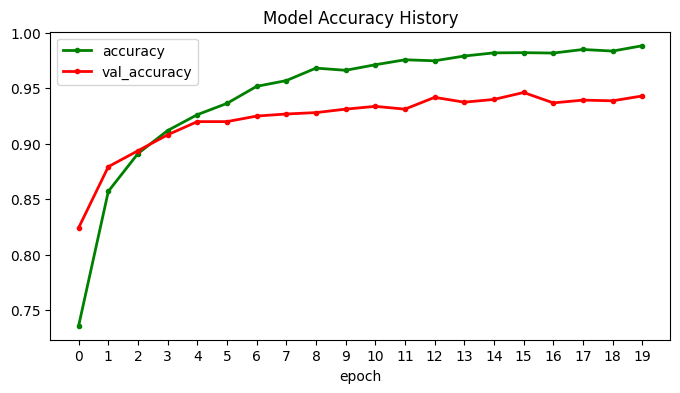

In [ ]:
#plots for efficientnet
plt.figure(figsize=(8,4))
plt.plot(history.history['sparse_categorical_accuracy'], '.g-', linewidth=2,label="accuracy")
plt.plot(history.history['val_sparse_categorical_accuracy'], '.r-', linewidth=2,label="val_accuracy")
plt.title('Model Accuracy History')
plt.xlabel('epoch')
plt.xticks([x for x in range(epochs)])
plt.legend()
plt.show()


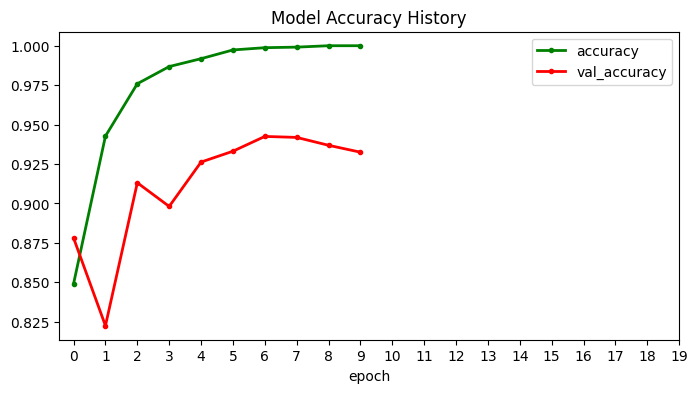

In [ ]:
#plot for vgg
plt.figure(figsize=(8,4))
plt.plot(history1.history['sparse_categorical_accuracy'], '.g-', linewidth=2,label="accuracy")
plt.plot(history1.history['val_sparse_categorical_accuracy'], '.r-', linewidth=2,label="val_accuracy")
plt.title('Model Accuracy History')
plt.xlabel('epoch')
plt.xticks([x for x in range(epochs)])
plt.legend()
plt.show()

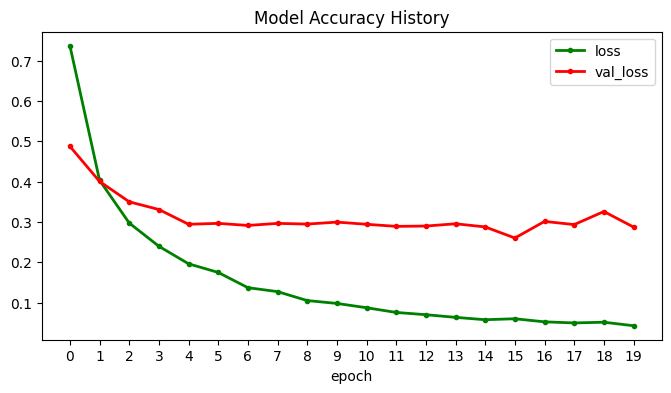

In [ ]:
#plots for efficientnet
plt.figure(figsize=(8,4))
plt.plot(history.history['loss'], '.g-', linewidth=2,label="loss")
plt.plot(history.history['val_loss'], '.r-', linewidth=2,label="val_loss")
plt.title('Model Accuracy History')
plt.xlabel('epoch')
plt.xticks([x for x in range(epochs)])
plt.legend()
plt.show()


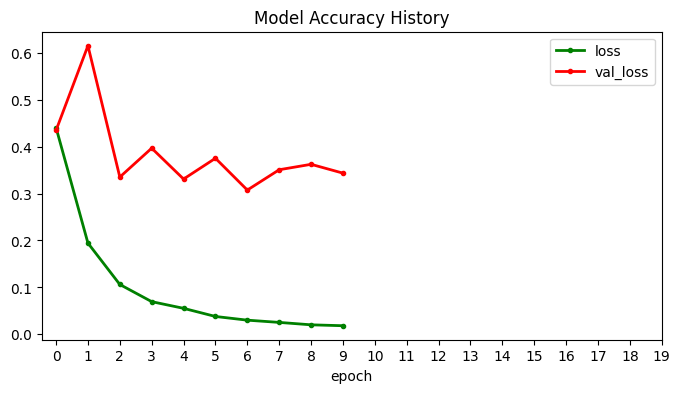

In [ ]:
#plots for vgg
plt.figure(figsize=(8,4))
plt.plot(history1.history['loss'], '.g-', linewidth=2,label="loss")
plt.plot(history1.history['val_loss'], '.r-', linewidth=2,label="val_loss")
plt.title('Model Accuracy History')
plt.xlabel('epoch')
plt.xticks([x for x in range(epochs)])
plt.legend()
plt.show()

In [14]:
from tensorflow.keras.models import load_model
vgg_model = load_model(
"/content/drive/MyDrive/Brain_Tumor_Project/best_model_vgg.keras"
)
eff_model = load_model(
"/content/drive/MyDrive/Brain_Tumor_Project/best_model_eff.keras"
)

In [ ]:
#for vgg
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import seaborn as sns
from sklearn.preprocessing import label_binarize
import numpy as np
test_images = open_images(test_paths) 
test_labels_encoded = encode_label(test_labels)  
test_predictions_vgg = vgg_model.predict(test_images)

print("Classification Report:")
print(classification_report(test_labels_encoded, np.argmax(test_predictions_vgg, axis=1)))

50/50 ━━━━━━━━━━━━━━━━━━━━ 25s 196ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.92      1.00      0.96       400
           1       0.98      0.98      0.98       400
           2       0.98      0.80      0.88       400
           3       0.89      0.97      0.93       400

    accuracy                           0.94      1600
   macro avg       0.94      0.94      0.94      1600
weighted avg       0.94      0.94      0.94      1600



In [ ]:
#for efficient
test_images = open_images_eff(test_paths)  
test_labels_encoded = encode_label(test_labels)  
test_predictions_eff= eff_model.predict(test_images)

print("Classification Report:")
print(classification_report(test_labels_encoded, np.argmax(test_predictions_eff, axis=1)))

50/50 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.93      1.00      0.96       400
           1       0.98      1.00      0.99       400
           2       0.98      0.82      0.89       400
           3       0.91      0.97      0.94       400

    accuracy                           0.95      1600
   macro avg       0.95      0.95      0.94      1600
weighted avg       0.95      0.95      0.94      1600



Confusion Matrix:
[[400   0   0   0]
 [  0 393   2   5]
 [ 35   3 321  41]
 [  2   6   3 389]]


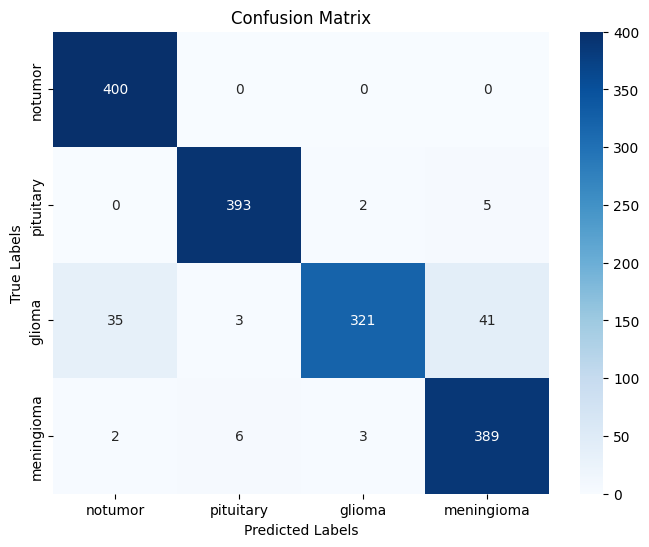

In [ ]:
# 3. Confusion Matrix for vgg
conf_matrix = confusion_matrix(test_labels_encoded, np.argmax(test_predictions_vgg, axis=1))
print("Confusion Matrix:")
print(conf_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True,fmt="d",cmap="Blues", xticklabels=os.listdir(train_dir), yticklabels=os.listdir(train_dir))
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()


Confusion Matrix:
[[400   0   0   0]
 [  0 399   0   1]
 [ 29   5 327  39]
 [  1   4   7 388]]


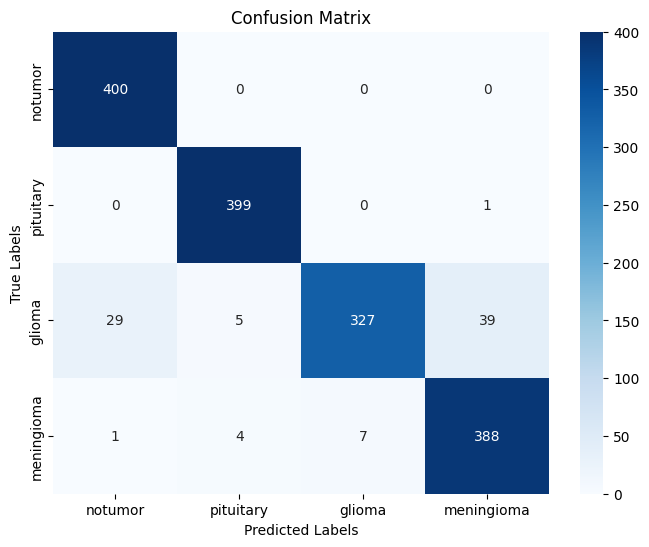

In [ ]:
# 3. Confusion Matrix for eff
conf_matrix = confusion_matrix(test_labels_encoded, np.argmax(test_predictions_eff, axis=1))
print("Confusion Matrix:")
print(conf_matrix)
# Plot the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True,fmt="d",cmap="Blues", xticklabels=os.listdir(train_dir), yticklabels=os.listdir(train_dir))
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()


50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step


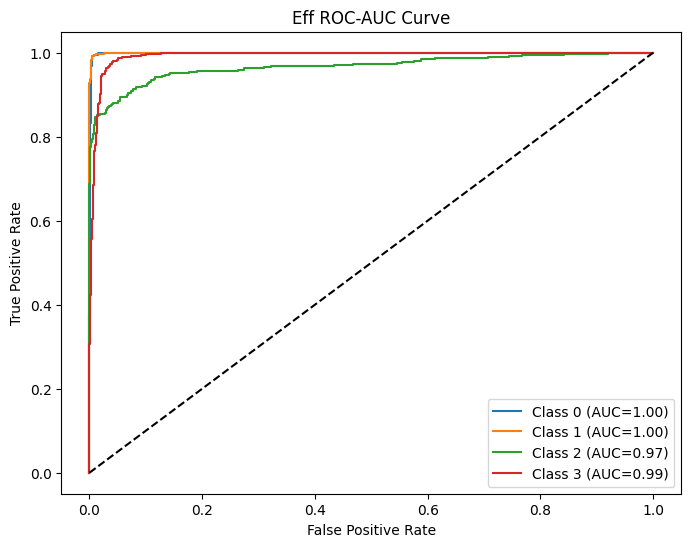

In [ ]:
#for efficient
test_images = open_images_eff(test_paths)  
test_labels_encoded = encode_label(test_labels)  
from sklearn.preprocessing import label_binarize
test_labels_bin = label_binarize(
    test_labels_encoded,
    classes=[0,1,2,3]
)
test_predictions_eff= eff_model.predict(test_images)
plt.figure(figsize=(8,6))

for i in range(4):
    fpr, tpr, _ = roc_curve(
        test_labels_bin[:, i],
        test_predictions_eff[:, i]
    )

    roc_auc = auc(fpr, tpr)
    plt.plot(
        fpr,
        tpr,
        label=f"Class {i} (AUC={roc_auc:.2f})"
    )
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Eff ROC-AUC Curve")

plt.legend()
plt.show()

50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 195ms/step


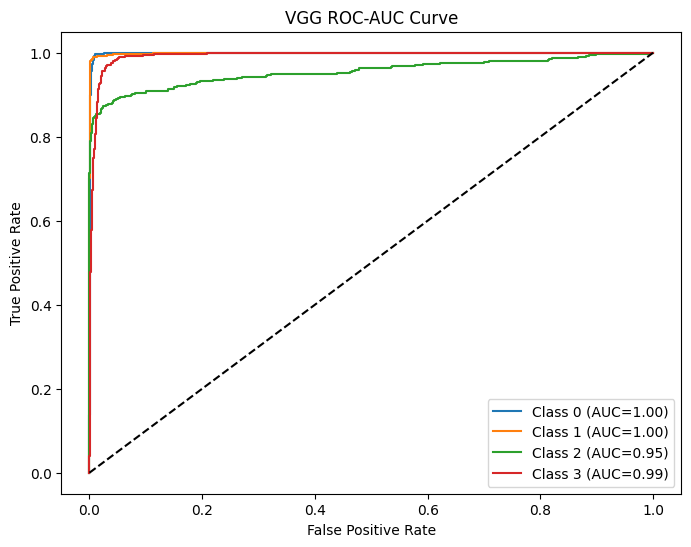

In [ ]:
#for vgg
test_images = open_images(test_paths)  
test_labels_encoded = encode_label(test_labels)  
from sklearn.preprocessing import label_binarize
test_labels_bin = label_binarize(
    test_labels_encoded,
    classes=[0,1,2,3]
)
test_predictions_vgg= vgg_model.predict(test_images)
plt.figure(figsize=(8,6))

for i in range(4):
    fpr, tpr, _ = roc_curve(
        test_labels_bin[:, i],
        test_predictions_vgg[:, i]
    )
    roc_auc = auc(fpr, tpr)
    plt.plot(
        fpr,
        tpr,
        label=f"Class {i} (AUC={roc_auc:.2f})"
    )
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("VGG ROC-AUC Curve")

plt.legend()
plt.show()

In [ ]:
class_labels = os.listdir(train_dir)
print(class_labels)

['notumor', 'pituitary', 'glioma', 'meningioma']


In [ ]:
#final prediction on testing data
from keras.preprocessing.image import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt
class_labels = ['notumor', 'pituitary', 'glioma', 'meningioma']
def detect_and_display(img_path, model, image_size=224):
    try:
        # Load image
        img = load_img(
            img_path,
            target_size=(image_size, image_size)
        )
        img_array = img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)
        predictions = model.predict(img_array)
        predicted_class_index = np.argmax(predictions, axis=1)[0]
        confidence_score = np.max(predictions, axis=1)[0]
        predicted_class = class_labels[predicted_class_index]
        if predicted_class == "notumor":
            result = "No Tumor"
        else:
            result = f"Tumor: {predicted_class}"
        plt.figure(figsize=(5,5))
        plt.imshow(load_img(img_path))
        plt.axis("off")
        plt.title(
            f"{result}\nConfidence: {confidence_score*100:.2f}%"
        )
        plt.show()
    except Exception as e:
        print("Error:", str(e))

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step


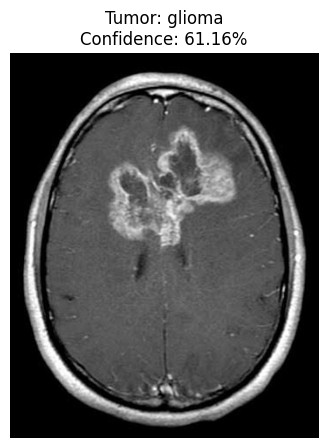

In [15]:
path="/content/brain_mri/Testing/glioma/Te-gl_1.jpg"
detect_and_display(path,eff_model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 402ms/step


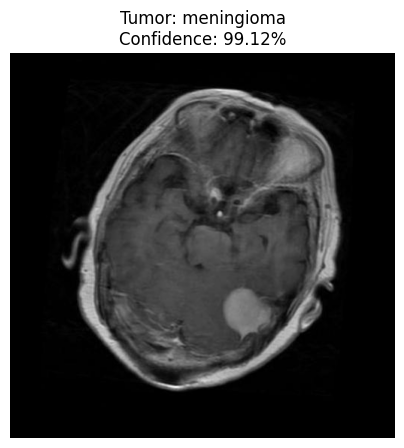

In [16]:
path="/content/brain_mri/Testing/meningioma/Te-aug-me_1.jpg"
detect_and_display(path,eff_model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 387ms/step


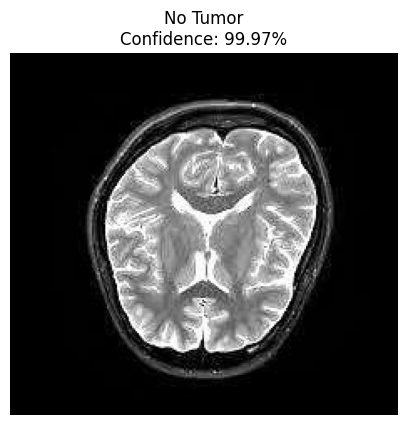

In [17]:
path="/content/brain_mri/Testing/notumor/Te-no_105.jpg"
detect_and_display(path,eff_model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step


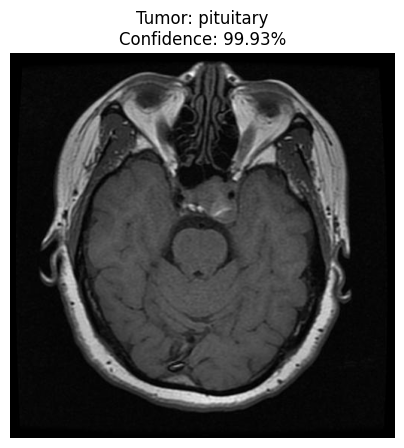

In [18]:
path="/content/brain_mri/Testing/pituitary/Te-pi_165.jpg"
detect_and_display(path,eff_model)